<a href="https://colab.research.google.com/github/Alexandre77777/computer_math/blob/main/5.%20%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0%20Pandas.%20%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9%20%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [40]:
%matplotlib inline
import pandas as pd
pd.__version__

'3.0.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [42]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [43]:
import numpy as np

# В исходном файле значения разделены ", " -> у строк есть ведущий пробел (' Private', ' >50K').
# Убираем лишние пробелы, чтобы дальше можно было сравнивать значения напрямую.
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].str.strip()
df.head(3)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


1) Выведите последние 10 элеметнов датасета

In [44]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [45]:
n_rows, n_cols = df.shape
print(f"Строк: {n_rows}, колонок: {n_cols}")

Строк: 32561, колонок: 15


3) Какие типы данных у элементов этого датасета?

In [46]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

4) Какие признаки имеют пропуски?

In [47]:
missing = df.isna().sum()
print("Признаки с пропусками (количество пропусков):")
print(missing[missing > 0])
print()
both = df[['workclass', 'occupation']].isna().all(axis=1).sum()
print(f"Строк, где пропущены одновременно workclass и occupation: {both}")

Признаки с пропусками (количество пропусков):
workclass         1836
occupation        1843
native.country     583
dtype: int64

Строк, где пропущены одновременно workclass и occupation: 1836


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

**Ваш ответ:**

Пропуски (в исходном файле они закодированы символом `?`) есть в признаках `workclass`, `occupation` и `native.country`. Это данные переписи, которые собирались по анкетам, поэтому пропуски возникают не из-за технического сбоя, а по причинам, связанным с самими респондентами:

- `workclass` и `occupation` отсутствуют почти всегда одновременно: у человека нет места работы и профессии (безработные, не работавшие, неработающие пенсионеры, студенты, домохозяйки) или он не стал отвечать на вопрос. Небольшое число записей, где пропущена только `occupation`, относится к тем, у кого `workclass = Never-worked` (у них рабочий класс известен, а профессии нет).
- `native.country` пропущена, когда респондент не указал страну рождения (отказ отвечать, неполная анкета).

Значит, пропуски не случайны (missing not at random): они связаны с занятостью и с нежеланием раскрывать информацию. Поэтому при анализе их лучше не удалять бездумно, а либо выделить в отдельную категорию (например, `Unknown`), либо явно оценить, как исключение таких строк влияет на выводы.

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [48]:
n_wc = df['workclass'].nunique()
print(f"Различных рабочих классов (без учета пропусков): {n_wc}\n")
print(df['workclass'].value_counts())

Различных рабочих классов (без учета пропусков): 8

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


7) Какой средний возраст женщин и мужчин?

In [49]:
df.groupby('sex')['age'].mean()

sex
Female    36.858230
Male      39.433547
Name: age, dtype: float64

8) Постройте гистограмму(bar) распределения образования людей (education)

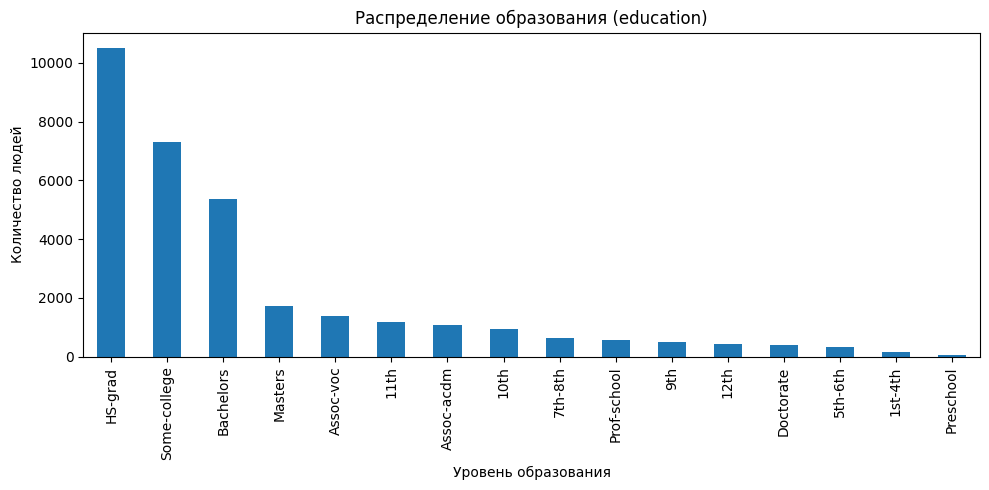

In [50]:
import matplotlib.pyplot as plt

ax = df['education'].value_counts().plot(kind='bar', figsize=(10, 5))
ax.set_title('Распределение образования (education)')
ax.set_xlabel('Уровень образования')
ax.set_ylabel('Количество людей')
plt.tight_layout()
plt.show()

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [51]:
stats = df.groupby('income')['age'].agg(['mean', 'std'])
stats.columns = ['Средний возраст', 'Среднеквадратичное отклонение']
print(stats.round(2))

        Средний возраст  Среднеквадратичное отклонение
income                                                
<=50K             36.78                          14.02
>50K              44.25                          10.52


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [52]:
higher = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']

rich = df[df['income'] == '>50K']
share_higher = rich['education'].isin(higher).mean()
print(f"Доля людей с доходом >50K, имеющих как минимум высшее образование: {share_higher:.1%}")
print(f"Есть ли среди получающих >50K люди без высшего образования? {(~rich['education'].isin(higher)).any()}")
print("Утверждение верно" if share_higher == 1 else "Утверждение неверно: доля меньше 100%")
print("\nОбразование людей с доходом >50K:")
print(rich['education'].value_counts())

Доля людей с доходом >50K, имеющих как минимум высшее образование: 57.8%
Есть ли среди получающих >50K люди без высшего образования? True
Утверждение неверно: доля меньше 100%

Образование людей с доходом >50K:
education
Bachelors       2221
HS-grad         1675
Some-college    1387
Masters          959
Prof-school      423
Assoc-voc        361
Doctorate        306
Assoc-acdm       265
10th              62
11th              60
7th-8th           40
12th              33
9th               27
5th-6th           16
1st-4th            6
Name: count, dtype: int64


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [53]:
men = df[df['sex'] == 'Male']
is_married = men['marital.status'].str.startswith('Married')

share_married = (men[is_married]['income'] == '>50K').mean()
share_single = (men[~is_married]['income'] == '>50K').mean()

print(f"Доля зарабатывающих >50K среди женатых мужчин : {share_married:.1%}")
print(f"Доля зарабатывающих >50K среди холостых мужчин: {share_single:.1%}")
print("Больше доля среди", "женатых" if share_married > share_single else "холостых")

Доля зарабатывающих >50K среди женатых мужчин : 44.1%
Доля зарабатывающих >50K среди холостых мужчин: 8.4%
Больше доля среди женатых


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



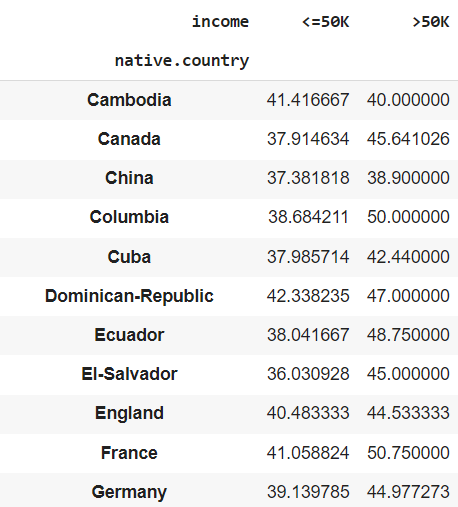

In [54]:
pivot_hours = df.pivot_table(index='native.country', columns='income',
                             values='hours.per.week', aggfunc='mean')
pivot_hours

income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

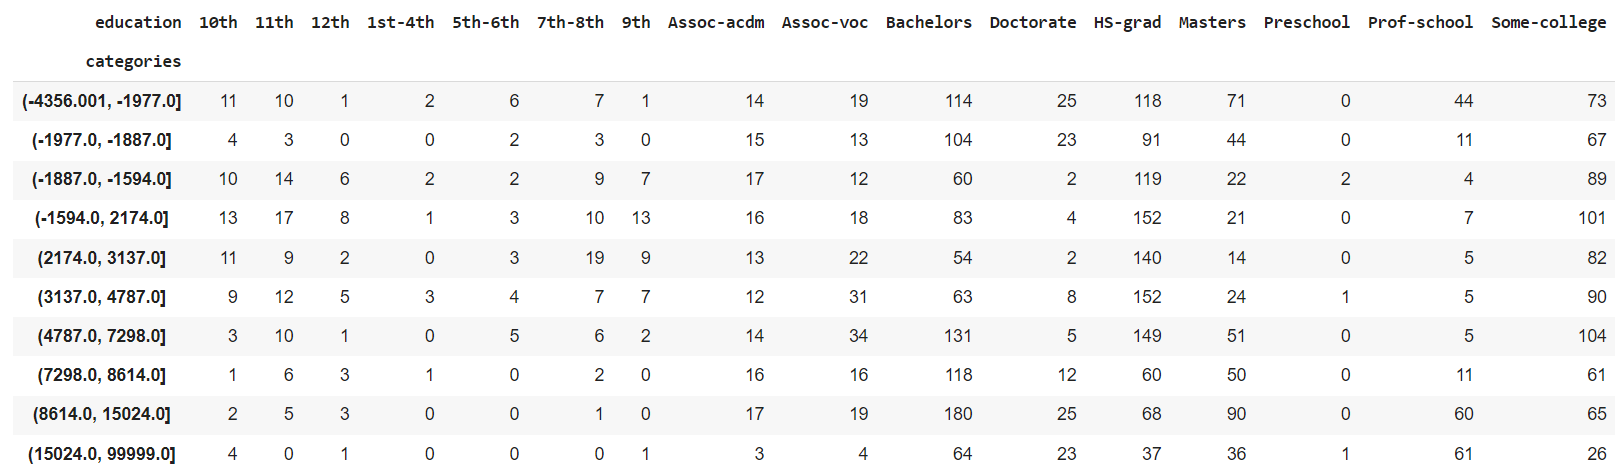

In [55]:
# 1-2. Вспомогательная таблица: education и разность capital.gain - capital.loss
summary_table = pd.DataFrame({'education': df['education'],
                              'capital.diff': df['capital.gain'] - df['capital.loss']})

# 3. Удаляем строки, где capital.diff равно нулю
summary_table = summary_table[summary_table['capital.diff'] != 0]

# 4-5. Делим значения на 10 категорий с помощью pd.qcut()
summary_table['categories'] = pd.qcut(summary_table['capital.diff'], q=10)

# 6. Сводная таблица: количество людей в каждой группе
pivot_edu = summary_table.pivot_table(index='categories', columns='education',
                                      values='capital.diff', aggfunc='count', observed=False)
pivot_edu

education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
categories,,,,,,,,,,,,,,,,
"(-4356.001, -1977.0]",11,10,1,2,6,7,1,14,19,114,25,118,71,0,44,73
"(-1977.0, -1887.0]",4,3,0,0,2,3,0,15,13,104,23,91,44,0,11,67
"(-1887.0, -1594.0]",10,14,6,2,2,9,7,17,12,60,2,119,22,2,4,89
"(-1594.0, 2174.0]",13,17,8,1,3,10,13,16,18,83,4,152,21,0,7,101
"(2174.0, 3137.0]",11,9,2,0,3,19,9,13,22,54,2,140,14,0,5,82
"(3137.0, 4787.0]",9,12,5,3,4,7,7,12,31,63,8,152,24,1,5,90
"(4787.0, 7298.0]",3,10,1,0,5,6,2,14,34,131,5,149,51,0,5,104
"(7298.0, 8614.0]",1,6,3,1,0,2,0,16,16,118,12,60,50,0,11,61
"(8614.0, 15024.0]",2,5,3,0,0,1,0,17,19,180,25,68,90,0,60,65


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [56]:
women = df[df['sex'] == 'Female'].copy()
women['rich'] = (women['income'] == '>50K')

by_country = women.groupby('native.country')['rich'].agg(['mean', 'sum', 'count'])
by_country.columns = ['Доля >50K', 'Кол-во >50K', 'Всего женщин']
by_country = by_country.sort_values('Доля >50K', ascending=False)

print("Топ-10 стран по доле женщин с доходом >50K (все страны):")
print(by_country.head(10))
print("\nТо же, но только для стран, где в выборке не менее 20 женщин (чтобы исключить случайные выбросы):")
print(by_country[by_country['Всего женщин'] >= 20].head(10))

Топ-10 стран по доле женщин с доходом >50K (все страны):
                Доля >50K  Кол-во >50K  Всего женщин
native.country                                      
Yugoslavia       0.333333            1             3
Taiwan           0.266667            4            15
Japan            0.250000            5            20
France           0.250000            3            12
Iran             0.250000            2             8
China            0.238095            5            21
Italy            0.238095            5            21
Canada           0.230769            9            39
Scotland         0.200000            1             5
Greece           0.200000            1             5

То же, но только для стран, где в выборке не менее 20 женщин (чтобы исключить случайные выбросы):
                Доля >50K  Кол-во >50K  Всего женщин
native.country                                      
Japan            0.250000            5            20
China            0.238095            5           

15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [57]:
import numpy as np

np.random.seed(42)
# Для доходов <=50K - случайное число из [0, 50], для >50K - из [51, 200]
df['magic_salary'] = np.where(df['income'] == '<=50K',
                              np.random.randint(0, 51, len(df)),
                              np.random.randint(51, 201, len(df)))

avg_by_edu = df.groupby('education')['magic_salary'].mean().sort_values(ascending=False)
print("Средняя magic_salary по уровням образования:")
print(avg_by_edu.round(2))

Средняя magic_salary по уровням образования:
education
Doctorate       99.83
Prof-school     99.23
Masters         81.58
Bachelors       66.59
Assoc-voc       51.10
Assoc-acdm      49.11
Some-college    44.16
HS-grad         40.93
12th            33.11
10th            31.27
11th            30.69
9th             30.67
7th-8th         30.57
5th-6th         29.32
Preschool       27.82
1st-4th         25.63
Name: magic_salary, dtype: float64


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [1]:
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [6]:
df = pd.read_csv("train.csv")
df["datetime"] = pd.to_datetime(df['datetime'])
df["mnth"] = df['datetime'].dt.month
df["yr"] = df["datetime"].dt.year
df["weekday"] = df["datetime"].dt.weekday
del df["casual"]
del df["registered"]
del df["datetime"]
df = df.rename(columns={
    "humidity": "hum",
    "weather": "weathersit",
    "count": "cnt"
})

display(df.head())
df.describe()

,season,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,mnth,yr,weekday
0,1,0,0,1,9.84,14.395,81,0.0,16,1,2011,5
1,1,0,0,1,9.02,13.635,80,0.0,40,1,2011,5
2,1,0,0,1,9.02,13.635,80,0.0,32,1,2011,5
3,1,0,0,1,9.84,14.395,75,0.0,13,1,2011,5
4,1,0,0,1,9.84,14.395,75,0.0,1,1,2011,5


,season,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,mnth,yr,weekday
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,191.574132,6.521495,2011.501929,3.013963
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,181.144454,3.444373,0.500019,2.004585
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,1.000000,1.000000,2011.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,42.000000,4.000000,2011.000000,1.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,145.000000,7.000000,2012.000000,3.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,284.000000,10.000000,2012.000000,5.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,977.000000,12.000000,2012.000000,6.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weathersit  10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   hum         10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   cnt         10886 non-null  int64  
 9   mnth        10886 non-null  int32  
 10  yr          10886 non-null  int32  
 11  weekday     10886 non-null  int32  
dtypes: float64(3), int32(3), int64(6)
memory usage: 893.1 KB


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

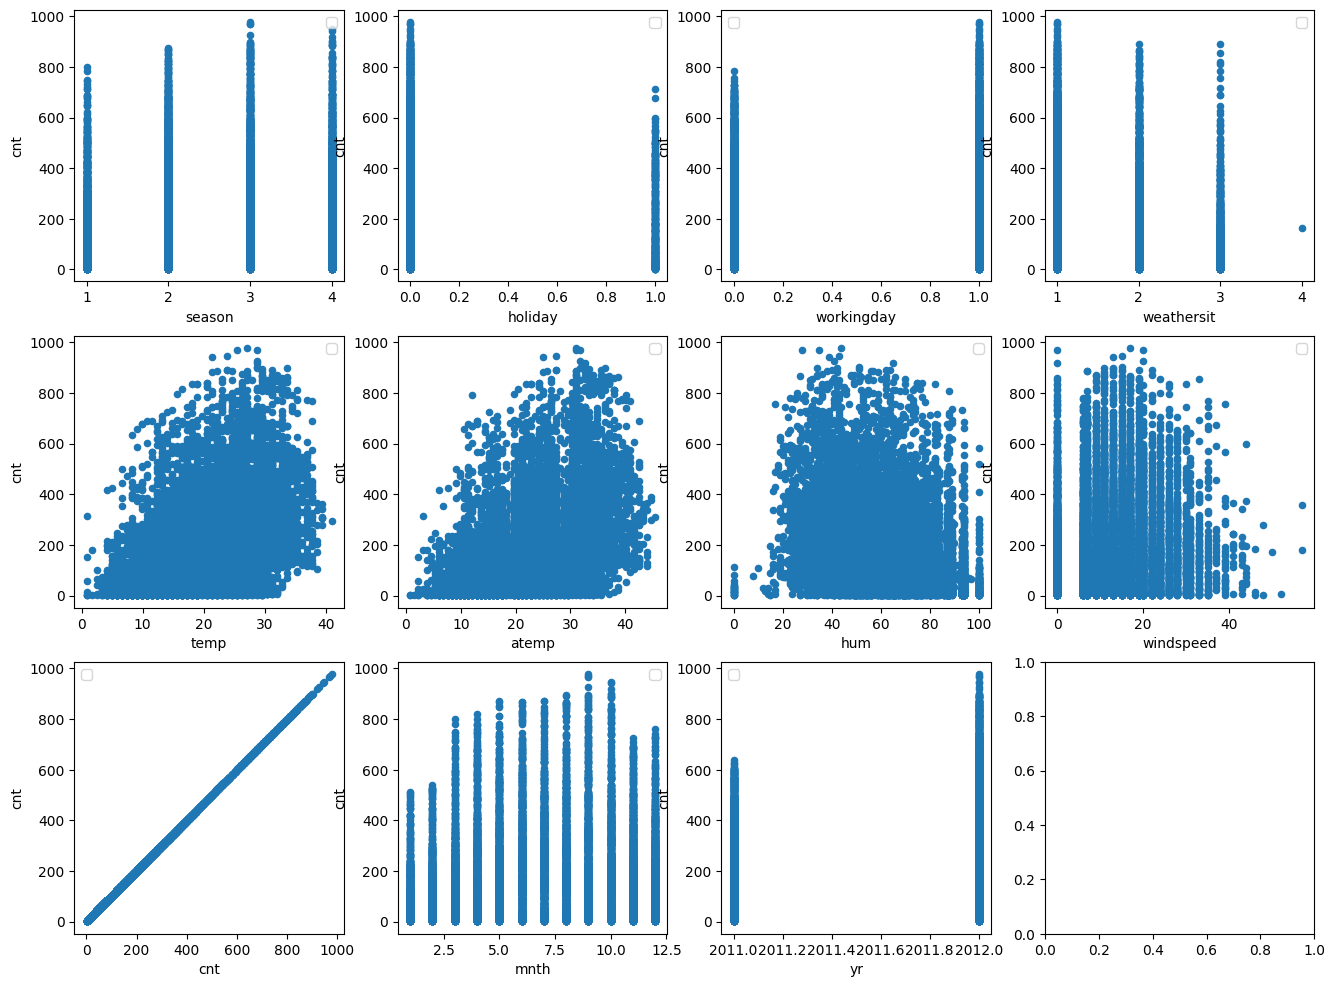

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





**Ответ:** зависимость числа прокатов от месяца нелинейная и сезонная: минимум приходится на зимние месяцы (январь, февраль, декабрь), затем число прокатов растет с весны, достигает максимума в теплый период (примерно с мая по сентябрь) и снова падает к зиме. График имеет форму «колокола» (одногорбая кривая): чем теплее месяц, тем больше прокатов, но к концу года спрос уменьшается вместе с температурой.

<Axes: xlabel='mnth'>

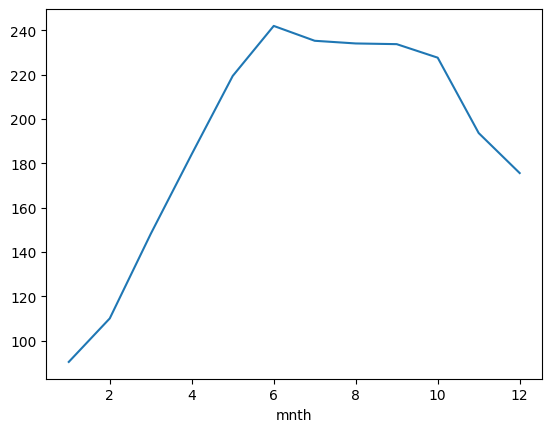

In [11]:
df.groupby("mnth")["cnt"].mean().plot()

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



**Ответ:** примерно линейно число прокатов растет с ростом температуры - признаки temp и atemp (чем теплее, тем больше прокатов, облако точек вытянуто вдоль восходящей прямой). Проверить это можно с помощью sns.lmplot / sns.regplot.

<Axes: xlabel='yr'>

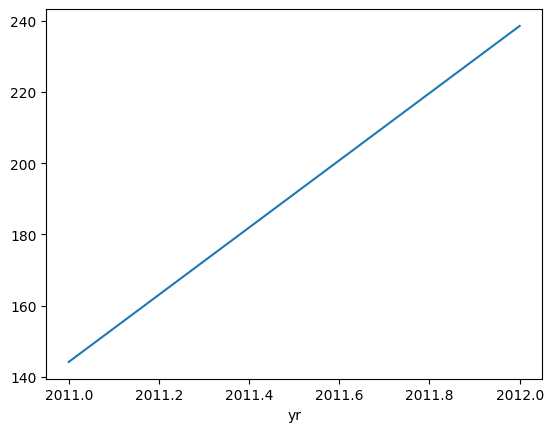

In [12]:
df.groupby("yr")["cnt"].mean().plot()

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



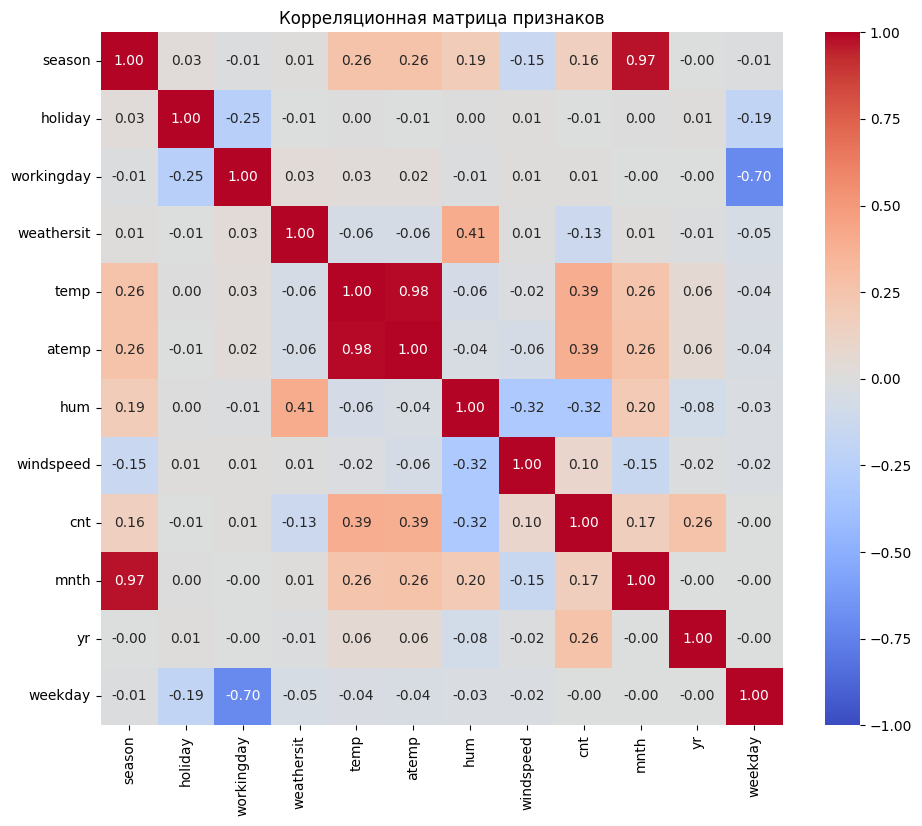

Корреляция признаков с cnt (по возрастанию модуля):
weekday      -0.002
holiday      -0.005
workingday    0.012
windspeed     0.101
weathersit   -0.129
season        0.163
mnth          0.167
yr            0.260
hum          -0.317
atemp         0.390
temp          0.394
Name: cnt, dtype: float64


In [14]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица признаков')
plt.show()

print("Корреляция признаков с cnt (по возрастанию модуля):")
print(corr['cnt'].drop('cnt').reindex(corr['cnt'].drop('cnt').abs().sort_values().index).round(3))

**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

**Ответ:** меньше всего с количеством прокатов коррелируют `holiday`, `workingday`, `weekday` и `hum` (влажность) - коэффициенты близки к нулю (по модулю около 0.1 и меньше). Больше всего - `temp` и `atemp` (около 0.63), затем `yr` (около 0.57) и `season` (около 0.4). Температура и «температура по ощущениям» коррелируют с `cnt` почти одинаково, потому что сами почти полностью дублируют друг друга.

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



<Axes: xlabel='yr,mnth'>

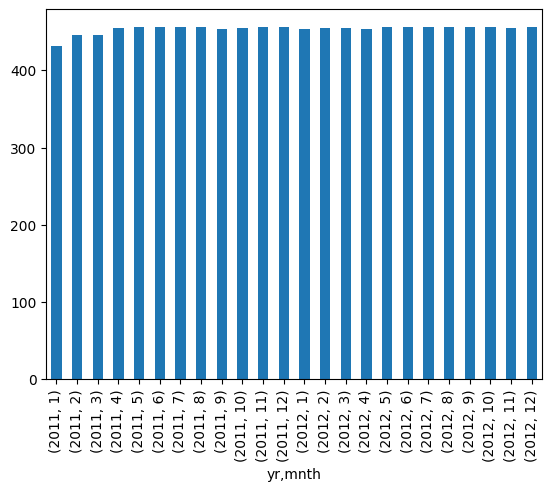

In [16]:
df.groupby(["yr", "mnth"])["cnt"].count().plot.bar()

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

**Ответ:** потому что в каждом месяце 2012 года прокатов заметно больше, чем в том же месяце 2011 года: сервис проката развивался и набирал популярность (больше пользователей и велосипедов), поэтому общий уровень спроса вырос. Год (`yr`) фактически отражает этот тренд роста, и признак сильно положительно коррелирует с `cnt`.

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



<Axes: xlabel='weekday,weathersit'>

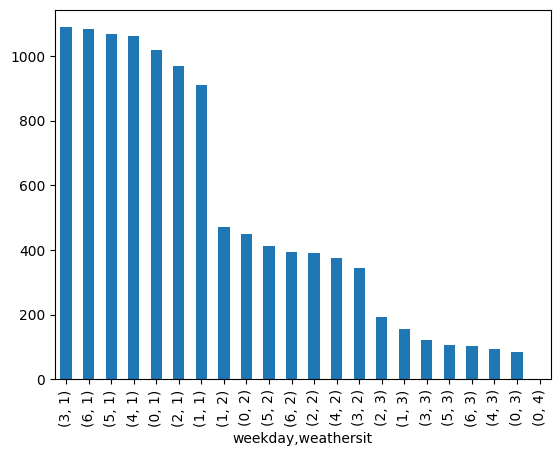

In [18]:
data = df[["weekday", "weathersit"]].value_counts()
data.plot.bar()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



**Ответ:** датасет составлен из ежедневных наблюдений за два полных года подряд без пропусков (2011-2012, около 731 дня), а не из случайной выборки: все дни недели представлены практически одинаковое число раз. Погода в основном благоприятная: преобладает `weathersit = 1` (ясно), реже `2` (облачно/туман), очень редко `3` (легкий дождь или снег), а категории `4` (ливень, сильный туман) в данных нет.

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?

**Ответ:** равномерное (дискретное равномерное) распределение - каждое значение от 0 до 6 встречается примерно одинаково часто.

### 5. Распределение

Постройте распределение целевого признака.


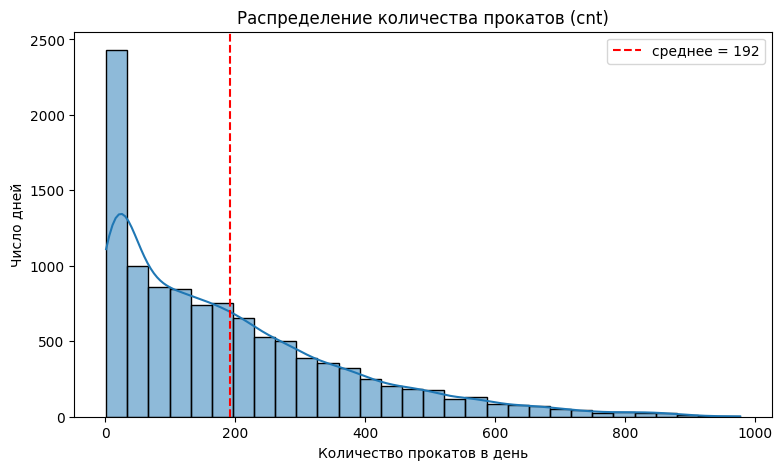

In [19]:
plt.figure(figsize=(9, 5))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title('Распределение количества прокатов (cnt)')
plt.xlabel('Количество прокатов в день')
plt.ylabel('Число дней')
plt.axvline(df['cnt'].mean(), color='red', linestyle='--', label=f"среднее = {df['cnt'].mean():.0f}")
plt.legend()
plt.show()


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

**Ответ:** в среднем приблизительно 4500 прокатов в день (основная масса дней лежит примерно в диапазоне от 3000 до 6500 прокатов; максимум - около 8700).

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



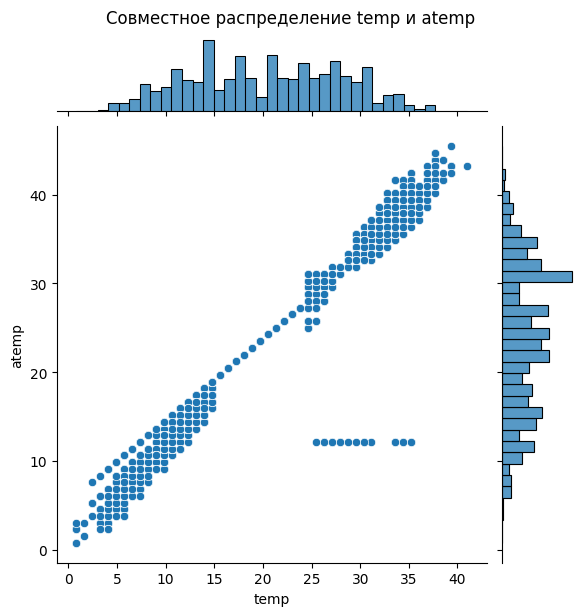

In [20]:
sns.jointplot(x='temp', y='atemp', data=df, kind='scatter')
plt.suptitle('Совместное распределение temp и atemp', y=1.02)
plt.show()

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

**Ответ:** да, настораживает: точки лежат практически на одной прямой, то есть температура и «температура по ощущениям» связаны почти функционально (коэффициент корреляции порядка 0.99). Это значит, что признаки дублируют друг друга (мультиколлинеарность): одного из них достаточно, а в линейных моделях наличие обоих делает оценки коэффициентов неустойчивыми. Обычно один из этих признаков удаляют.

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




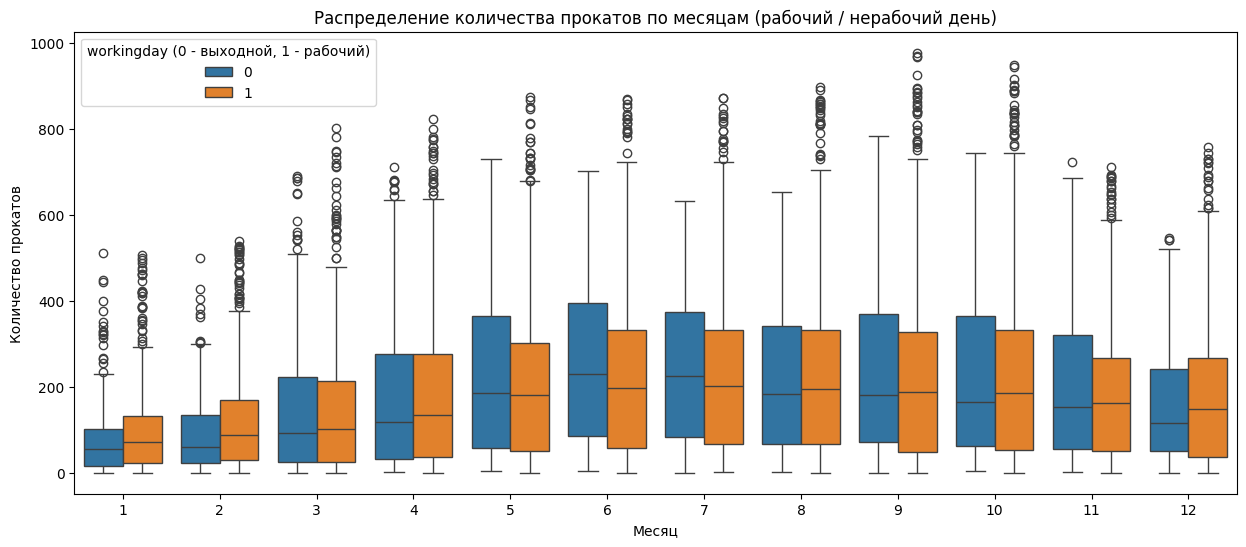

In [21]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='mnth', y='cnt', hue='workingday', data=df)
plt.title('Распределение количества прокатов по месяцам (рабочий / нерабочий день)')
plt.xlabel('Месяц')
plt.ylabel('Количество прокатов')
plt.legend(title='workingday (0 - выходной, 1 - рабочий)')
plt.show()

**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

**Ответ:** в будние дни велосипеды берут для поездок на работу и учебу, поэтому в месяцы с менее комфортной погодой, когда прогулок мало, будничный спрос устойчивее и медиана в рабочие дни выше. В теплые месяцы люди больше катаются ради отдыха, поэтому в выходные (нерабочие) дни спрос выравнивается с будничным или превышает его. Конкретные месяцы, где перевес на стороне будней или выходных, определяются по построенному боксплоту.

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [2]:
!pip install seaborn==0.11.0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.13.2
    Uninstalling seaborn-0.13.2:
      Successfully uninstalled seaborn-0.13.2


ModuleNotFoundError: No module named 'distutils'

In [3]:
colab = False # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [4]:
if colab:
    df = pd.read_csv('/content/drive/My Drive/Data/StudentsPerformance.csv')
else:
    df = pd.read_csv("StudentsPerformance.csv")

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


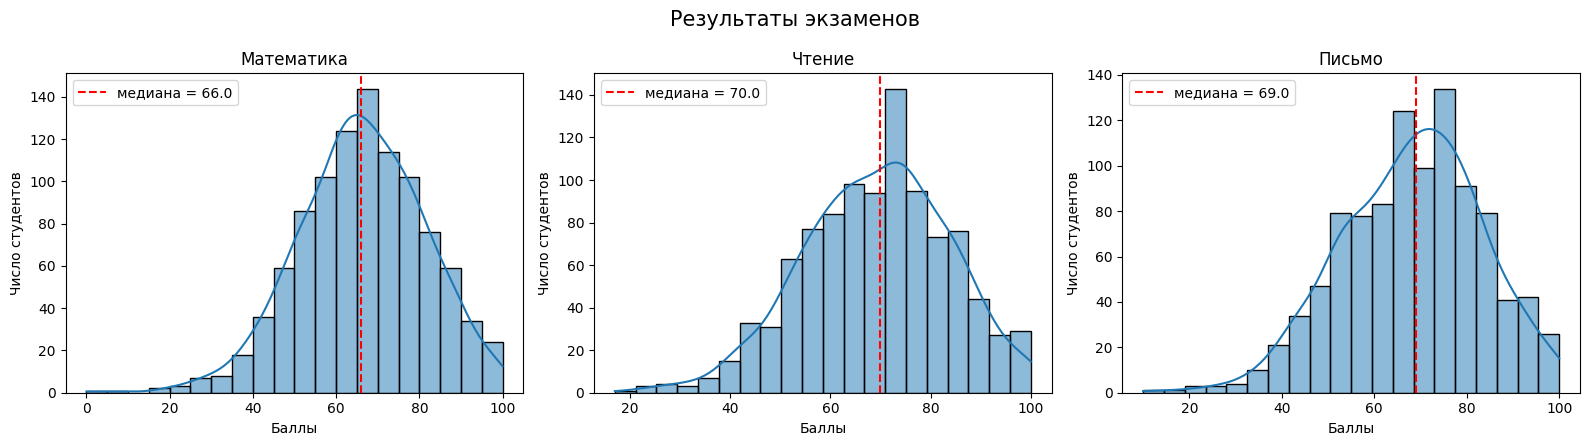

Медианные значения:
math score       66.0
reading score    70.0
writing score    69.0
dtype: float64


In [28]:
scores = ['math score', 'reading score', 'writing score']
titles = ['Математика', 'Чтение', 'Письмо']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(axes, scores, titles):
    sns.histplot(df[col], bins=20, kde=True, ax=ax)
    med = df[col].median()
    ax.axvline(med, color='red', linestyle='--', label=f'медиана = {med:.1f}')
    ax.set_title(title)
    ax.set_xlabel('Баллы')
    ax.set_ylabel('Число студентов')
    ax.legend()
fig.suptitle('Результаты экзаменов', fontsize=15)
plt.tight_layout()
plt.show()

print("Медианные значения:")
print(df[scores].median())

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


Уровни образования родителей и число студентов:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


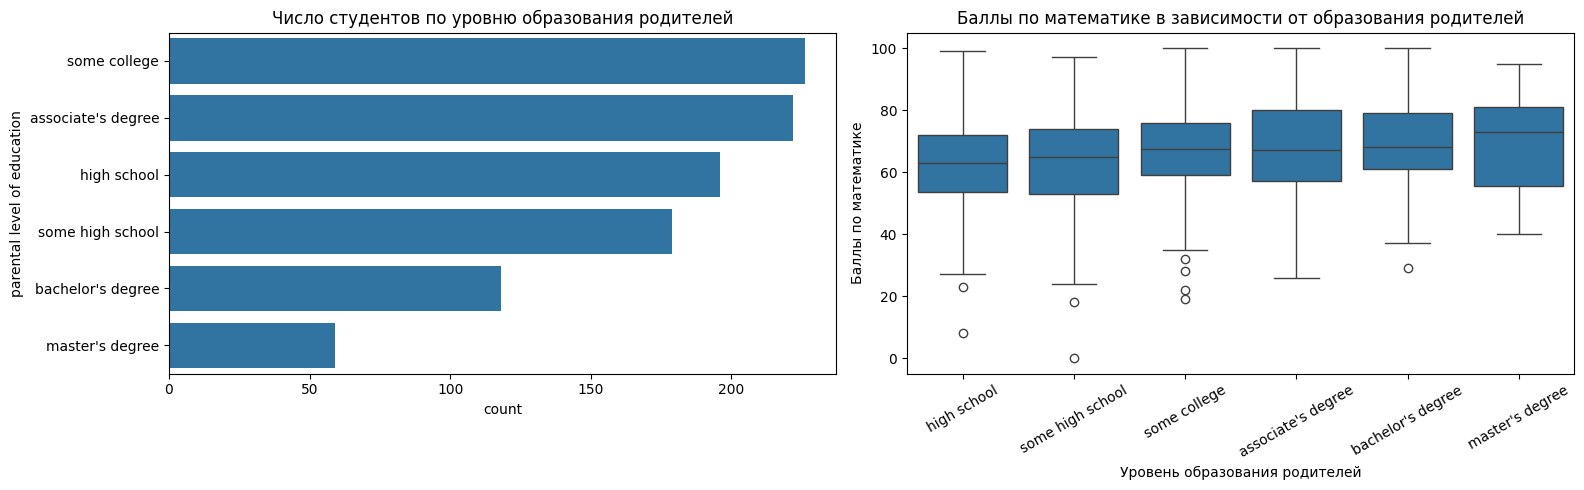


Средний балл по математике:
parental level of education
high school           62.14
some high school      63.50
some college          67.13
associate's degree    67.88
bachelor's degree     69.39
master's degree       69.75
Name: math score, dtype: float64

Вывод: баллы различаются - от 62.1 (high school) до 69.7 (master's degree), но различие умеренное, а распределения внутри групп сильно перекрываются.


In [29]:
edu_col = 'parental level of education'

print("Уровни образования родителей и число студентов:")
print(df[edu_col].value_counts())

order = df.groupby(edu_col)['math score'].mean().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(y=edu_col, data=df, order=df[edu_col].value_counts().index, ax=axes[0])
axes[0].set_title('Число студентов по уровню образования родителей')
sns.boxplot(x=edu_col, y='math score', data=df, order=order, ax=axes[1])
axes[1].set_title('Баллы по математике в зависимости от образования родителей')
axes[1].set_xlabel('Уровень образования родителей')
axes[1].set_ylabel('Баллы по математике')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

means = df.groupby(edu_col)['math score'].mean().sort_values()
print("\nСредний балл по математике:")
print(means.round(2))
print(f"\nВывод: баллы различаются - от {means.iloc[0]:.1f} ({means.index[0]}) "
      f"до {means.iloc[-1]:.1f} ({means.index[-1]}), но различие умеренное, "
      f"а распределения внутри групп сильно перекрываются.")

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [30]:
top_girls = df[(df['gender'] == 'female') &
               (df['math score'] > 90) &
               (df['reading score'] > 90) &
               (df['writing score'] > 90)]
print(f"Число студенток, набравших больше 90 баллов по всем предметам: {len(top_girls)}")

Число студенток, набравших больше 90 баллов по всем предметам: 17


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [31]:
scores = ['math score', 'reading score', 'writing score']
df.groupby('gender')[scores].agg(['min', 'max', 'median'])

math score             reading score             writing score       \
              min  max median           min  max median           min  max   
gender                                                                       
female          0  100   65.0            17  100   73.0            10  100   
male           27  100   69.0            23  100   66.0            15  100   

               
       median  
gender         
female   74.0  
male     64.0

#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

In [32]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

avg_table = (df.groupby(['gender', 'lunch', 'test preparation course'])['average score']
               .agg(['mean', 'count']).round(2))
print(avg_table)

print("\nПо отдельным признакам (средний балл):")
print(df.groupby(['gender', 'lunch'])['average score'].mean().unstack().round(2))
print()
print(df.groupby(['gender', 'test preparation course'])['average score'].mean().unstack().round(2))

                                              mean  count
gender lunch        test preparation course              
female free/reduced completed                69.53     70
                    none                     59.50    119
       standard     completed                77.48    114
                    none                     70.96    215
male   free/reduced completed                65.72     61
                    none                     58.32    105
       standard     completed                73.51    113
                    none                     65.49    203

По отдельным признакам (средний балл):
lunch   free/reduced  standard
gender                        
female         63.22     73.22
male           61.04     68.36

test preparation course  completed   none
gender                                   
female                       74.45  66.88
male                         70.78  63.04


#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

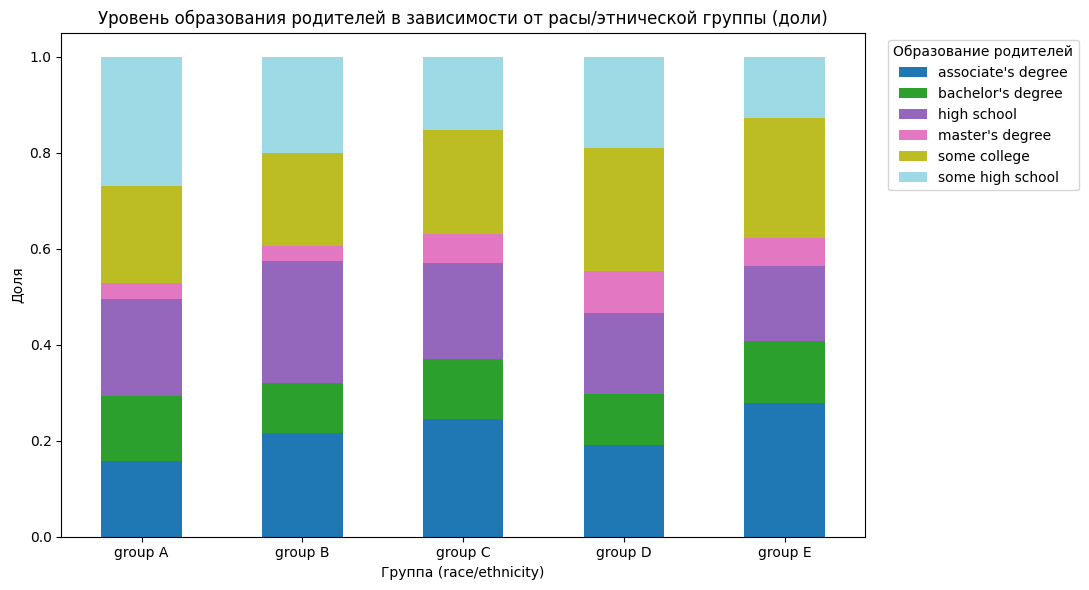

In [33]:
race_edu = pd.crosstab(df['race/ethnicity'], df['parental level of education'], normalize='index')

race_edu.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab20')
plt.title('Уровень образования родителей в зависимости от расы/этнической группы (доли)')
plt.xlabel('Группа (race/ethnicity)')
plt.ylabel('Доля')
plt.xticks(rotation=0)
plt.legend(title='Образование родителей', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

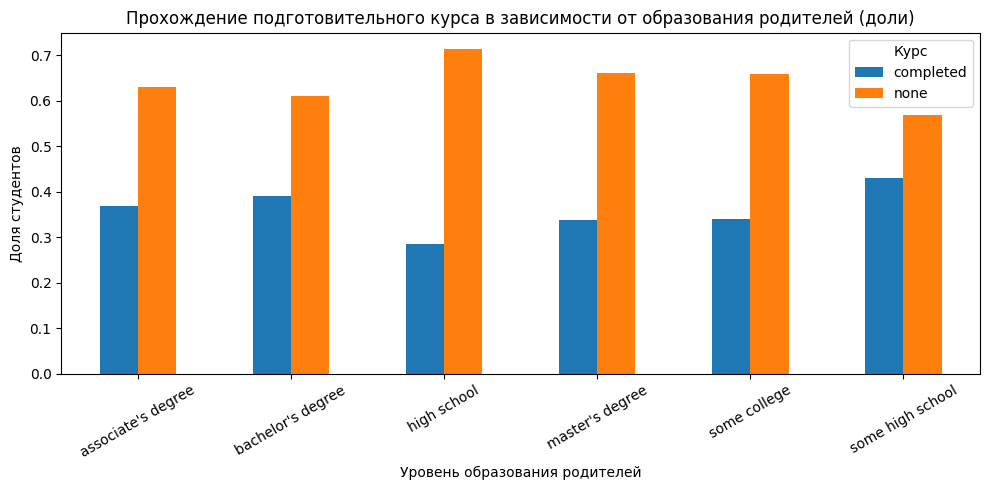

test preparation course      completed   none
parental level of education                  
associate's degree               0.369  0.631
bachelor's degree                0.390  0.610
high school                      0.286  0.714
master's degree                  0.339  0.661
some college                     0.341  0.659
some high school                 0.430  0.570

Доля прошедших курс: родители - только старшая школа: 28.6%; бакалавр: 39.0%; магистр: 33.9%
Чаще ходят на курсы: дети родителей с бакалавром/магистром


In [34]:
edu_prep = pd.crosstab(df['parental level of education'], df['test preparation course'], normalize='index')

edu_prep.plot(kind='bar', figsize=(10, 5))
plt.title('Прохождение подготовительного курса в зависимости от образования родителей (доли)')
plt.xlabel('Уровень образования родителей')
plt.ylabel('Доля студентов')
plt.xticks(rotation=30)
plt.legend(title='Курс')
plt.tight_layout()
plt.show()

print(edu_prep.round(3))
hs = edu_prep.loc['high school', 'completed']
uni = edu_prep.loc[["bachelor's degree", "master's degree"], 'completed']
print(f"\nДоля прошедших курс: родители - только старшая школа: {hs:.1%}; "
      f"бакалавр: {uni.iloc[0]:.1%}; магистр: {uni.iloc[1]:.1%}")
print("Чаще ходят на курсы:", "дети родителей с бакалавром/магистром" if uni.mean() > hs
      else "дети родителей, закончивших только старшую школу")

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

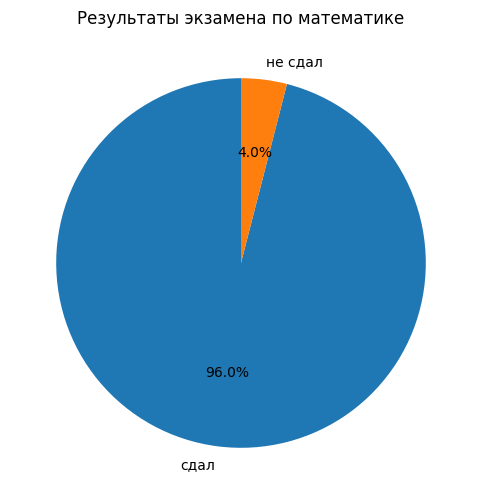

math result
сдал       960
не сдал     40
Name: count, dtype: int64


In [35]:
import numpy as np

df['math result'] = np.where(df['math score'] >= 40, 'сдал', 'не сдал')

df['math result'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), startangle=90)
plt.title('Результаты экзамена по математике')
plt.ylabel('')
plt.show()
print(df['math result'].value_counts())

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

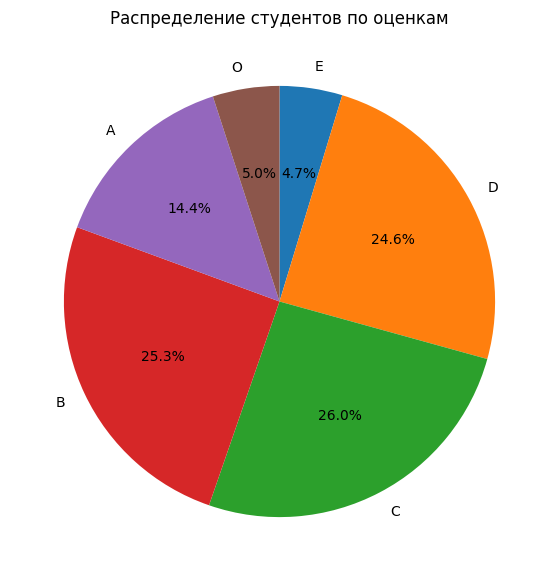

grade
E     47
D    246
C    260
B    253
A    144
O     50
Name: count, dtype: int64


In [36]:
# Средний балл за три экзамена
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Оценка по шкале: 0-40 -> E, 41-60 -> D, 61-70 -> C, 71-80 -> B, 81-90 -> A, 91-100 -> O
bins = [-1, 40, 60, 70, 80, 90, 100]
labels = ['E', 'D', 'C', 'B', 'A', 'O']
df['grade'] = pd.cut(df['average score'], bins=bins, labels=labels)

# Не сдавшим математику ставится E независимо от среднего балла
df.loc[df['math score'] < 40, 'grade'] = 'E'

grade_counts = df['grade'].value_counts().reindex(labels)
grade_counts.plot.pie(autopct='%1.1f%%', figsize=(7, 7), startangle=90, counterclock=False)
plt.title('Распределение студентов по оценкам')
plt.ylabel('')
plt.show()
print(grade_counts)

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

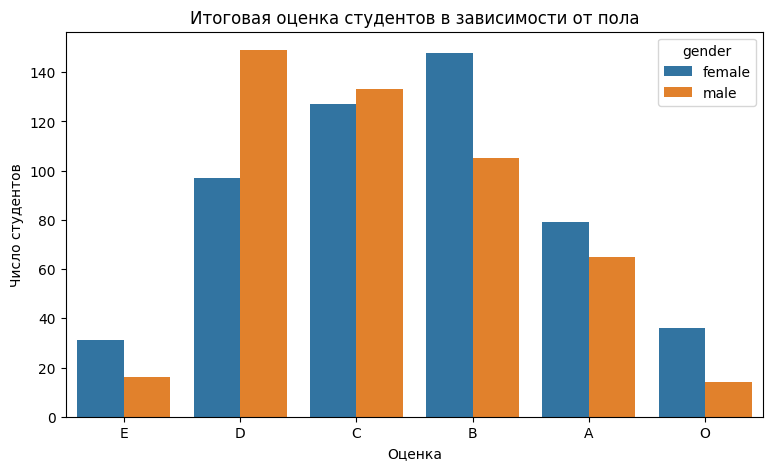

gender  female  male
grade               
O           36    14
A           79    65
B          148   105

Больше оценок O, A, B суммарно получили: женщины (female)


In [37]:
plt.figure(figsize=(9, 5))
sns.countplot(x='grade', hue='gender', data=df, order=['E', 'D', 'C', 'B', 'A', 'O'])
plt.title('Итоговая оценка студентов в зависимости от пола')
plt.xlabel('Оценка')
plt.ylabel('Число студентов')
plt.show()

top = pd.crosstab(df['grade'], df['gender']).loc[['O', 'A', 'B']]
print(top)
print("\nБольше оценок O, A, B суммарно получили:",
      "женщины (female)" if top['female'].sum() > top['male'].sum() else "мужчины (male)")